In [5]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [s]
>NUTS: [beta, sigma]


c:\ProgramData\anaconda3\envs\ra-route_network\Lib\site-packages\rich\live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 129 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0, 0]  1.399  0.297   0.705    1.873      0.055    0.065      49.0   
beta[0, 1] -0.169  0.441  -0.753    0.813      0.144    0.090      14.0   
beta[0, 2]  0.102  0.288  -0.451    0.683      0.040    0.029      56.0   
beta[1, 0]  1.292  0.352   0.482    1.798      0.047    0.027      58.0   
beta[1, 1] -0.024  0.511  -0.690    0.973      0.114    0.049      25.0   
beta[1, 2]  0.145  0.323  -0.455    0.789      0.050    0.017      42.0   
beta[2, 0]  1.034  0.398   0.289    1.696      0.067    0.083      36.0   
beta[2, 1]  0.603  0.419  -0.431    1.113      0.197    0.155       6.0   
beta[2, 2]  0.410  0.290  -0.183    0.943      0.115    0.048       7.0   
sigma       0.371  0.116   0.197    0.592      0.016    0.008      50.0   

            ess_tail  r_hat  
beta[0, 0]      31.0   1.09  
beta[0, 1]      24.0   1.12  
beta[0, 2]      50.0   1.03  
beta[1, 0]     184.0   1.01  
beta[1, 1]     116.0   1

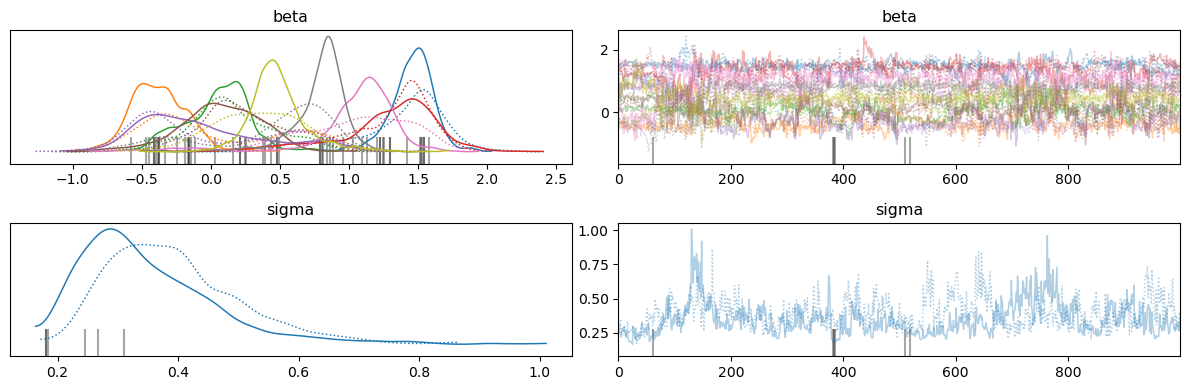

In [7]:
# Simulate synthetic data (simplified)
np.random.seed(42)
T = 30  # time steps (e.g., days)
num_features = 3  # temperature, humidity, hour

# Create environmental covariates
temperature = 25 + 5 * np.sin(np.linspace(0, 2 * np.pi, T)) + np.random.normal(0, 1, T)
humidity = 60 + 10 * np.cos(np.linspace(0, 2 * np.pi, T)) + np.random.normal(0, 3, T)
hour = np.random.choice([8, 12, 18], size=T)

# Feature matrix
X = np.column_stack([temperature, humidity, hour])
X = (X - X.mean(axis=0)) / X.std(axis=0)

# True states and beta values
true_states = np.array([0]*10 + [1]*10 + [2]*10)
true_betas = np.array([
    [1.0, 0.2, 0.3],
    [0.5, 0.5, 0.1],
    [1.5, -0.1, 0.2]
])
y = np.array([X[t] @ true_betas[true_states[t]] + np.random.normal(0, 0.5) for t in range(T)])

# --- PyMC Model ---
with pm.Model() as model:
    # Hidden states (categorical)
    s = pm.Categorical('s', p=np.ones(3)/3, shape=T)

    # Regime-specific betas
    beta = pm.Normal('beta', mu=0, sigma=1, shape=(3, num_features))
    sigma = pm.HalfNormal('sigma', sigma=1.0)

    # One-hot encode s and get beta for each t
    s_onehot = pm.math.eq(s[:, None], np.arange(3))  # shape (T, 3)
    beta_s = pm.math.dot(s_onehot, beta)             # shape (T, num_features)
    mu = pm.math.sum(X * beta_s, axis=1)

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

    # Compound sampler: Metropolis for s, NUTS for beta & sigma
    step1 = pm.Metropolis(vars=[s])
    step2 = pm.NUTS(vars=[beta, sigma])
    trace = pm.sample(1000, tune=500, step=[step1, step2], chains=2, return_inferencedata=True)

# --- Results ---
az_summary = az.summary(trace, var_names=["beta", "sigma"])
print(az_summary)

# visualize posteriors
az.plot_trace(trace, var_names=["beta", "sigma"])
plt.tight_layout()
plt.show()